
# **Project Title: Voice-Based Prediction of Parkinson’s Disease Severity**

##### **Student:       Suleman Mohammad**
##### **School:        Hood Graduate College, MS. Bioinformatics**
##### **Course:        BIFX-546 Machine Learning for Bioinformatics**
##### **Instructor:    Sarangan Ravichandran, Ph.D., PMP**    
##### **Dataset:       Parkinson's Telemonitoring**                                                               

**Disclaimer**: This repository contains analysis of my Final Project for my course  BIFX 546 – Machine Learning for Bioinformatics, focusing on the Parkinsons Telemonitoring dataset. The main goal of this project is to use biomedical voice features to predict clinical motor_UPDRS and total_UPDRS scores for patients with early-stage Parkinson’s disease.

#### =============================================================================
#### 1. DATASET LOADING
#### =============================================================================

##### LOADING THE REQUIRED PACKAGES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### ADDITIONAL PACKAGES WHICH ARE REQUIRED TO LOAD DATASET DIRECTLY FROM THE UCI REPO: 

In [2]:
##To install the ucimlrepo package, you can use the following command in your terminal or command prompt:
%pip install ucimlrepo

##In Jupyter Notebook, you can use the following command to install the ucimlrepo package:
!pip3 install -U ucimlrepo 

from ucimlrepo import fetch_ucirepo

Note: you may need to restart the kernel to use updated packages.


#####  LOADING THE DATASET USING DIFFERENT APPROACHES

**NOTE:** Select and implement the approach that best aligns with your methodology. Comment out any alternative approaches not used in the final implementation.

In [4]:
# 1. Load the dataset from the local CSV file
#df = pd.read_csv('Pakisons-Data-File.csv')

# 2. Load the dataset from the local excel file
#df = pd.read_excel('Pakisons-Data-File.xlsx')

#3. Load dataset using ucimlrepo package (alternative method  
# fetch dataset 
def new_func():
    parkinsons_telemonitoring = fetch_ucirepo(id=189)
    return parkinsons_telemonitoring

parkinsons_telemonitoring = new_func() 

# metadata 
print(parkinsons_telemonitoring.metadata)  
# variable information 
print(parkinsons_telemonitoring.variables) 
# Create a copy of the dataset for analysis
df = parkinsons_telemonitoring.data["original"].copy()


# Basic structure
df_shape = df.shape
n_patients = df["subject#"].nunique()
n_records = len(df)


{'uci_id': 189, 'name': 'Parkinsons Telemonitoring', 'repository_url': 'https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring', 'data_url': 'https://archive.ics.uci.edu/static/public/189/data.csv', 'abstract': "Oxford Parkinson's Disease Telemonitoring Dataset", 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 5875, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['motor_UPDRS', 'total_UPDRS'], 'index_col': ['subject#'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5ZS3N', 'creators': ['Athanasios Tsanas', 'Max Little'], 'intro_paper': {'ID': 229, 'type': 'NATIVE', 'title': "Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests", 'authors': 'A. Tsanas, Max A. Little, P. McSharry, L. Ramig', 'venue': 'IEEE Transactions on Bio

#### =============================================================================
#### 2. INITIAL DATA CLEANING
#### =============================================================================

In [5]:
# Check for missing values
missing_values = df.isnull().sum()

# Check for duplicates
duplicates = df.duplicated().sum()

# Check data types
print(df.dtypes)

# Drop the unnecessary index column
if "Unnamed: 0" in df.columns: 
    df = df.drop(columns=["Unnamed: 0"])
df.columns 

subject#           int64
age                int64
sex                int64
test_time        float64
Jitter(%)        float64
Jitter(Abs)      float64
Jitter:RAP       float64
Jitter:PPQ5      float64
Jitter:DDP       float64
Shimmer          float64
Shimmer(dB)      float64
Shimmer:APQ3     float64
Shimmer:APQ5     float64
Shimmer:APQ11    float64
Shimmer:DDA      float64
NHR              float64
HNR              float64
RPDE             float64
DFA              float64
PPE              float64
motor_UPDRS      float64
total_UPDRS      float64
dtype: object


Index(['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)',
       'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)',
       'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR',
       'HNR', 'RPDE', 'DFA', 'PPE', 'motor_UPDRS', 'total_UPDRS'],
      dtype='str')

#### =============================================================================
#### 3. SUMMARY STATISTICS
#### =============================================================================

In [6]:
# Basic descriptive statistics 
summary = df.describe()

#Target Variable statistics
motor_stats = { 
   "mean": df["motor_UPDRS"].mean(), 
   "median": df["motor_UPDRS"].median(), 
   "std": df["motor_UPDRS"].std(), 
   "min": df["motor_UPDRS"].min(), 
   "max": df["motor_UPDRS"].max() 
   }

total_stats = { 
   "mean": df["total_UPDRS"].mean(), 
   "median": df["total_UPDRS"].median(), 
   "std": df["total_UPDRS"].std(), 
   "min": df["total_UPDRS"].min(), 
   "max": df["total_UPDRS"].max() 
   }

#Demographics 
Age_mean = df["age"].mean()
Age_min = df["age"].min()
Age_max = df["age"].max() 

#Gender Distribution
# Male =0 and Female =1
Male =  {(df['sex'] == 0).sum()}
Female = {(df['sex'] == 1).sum()}

#Recording Period
duration_start = df['test_time'].min()
duration_end = df['test_time'].max()
average_recordings_per_patient = len(df) / df['subject#'].nunique()

Duration = (
    f"Recording period: {duration_start:.1f} to {duration_end:.1f} days since recruitment"
)
Average_recordings_per_patient = (
    f"Average recordings per patient: {average_recordings_per_patient:.1f}"
)

print(Duration)
print(Average_recordings_per_patient)

Recording period: -4.3 to 215.5 days since recruitment
Average recordings per patient: 139.9


#### =============================================================================
#### 4. VISUALIZATIONS
#### =============================================================================

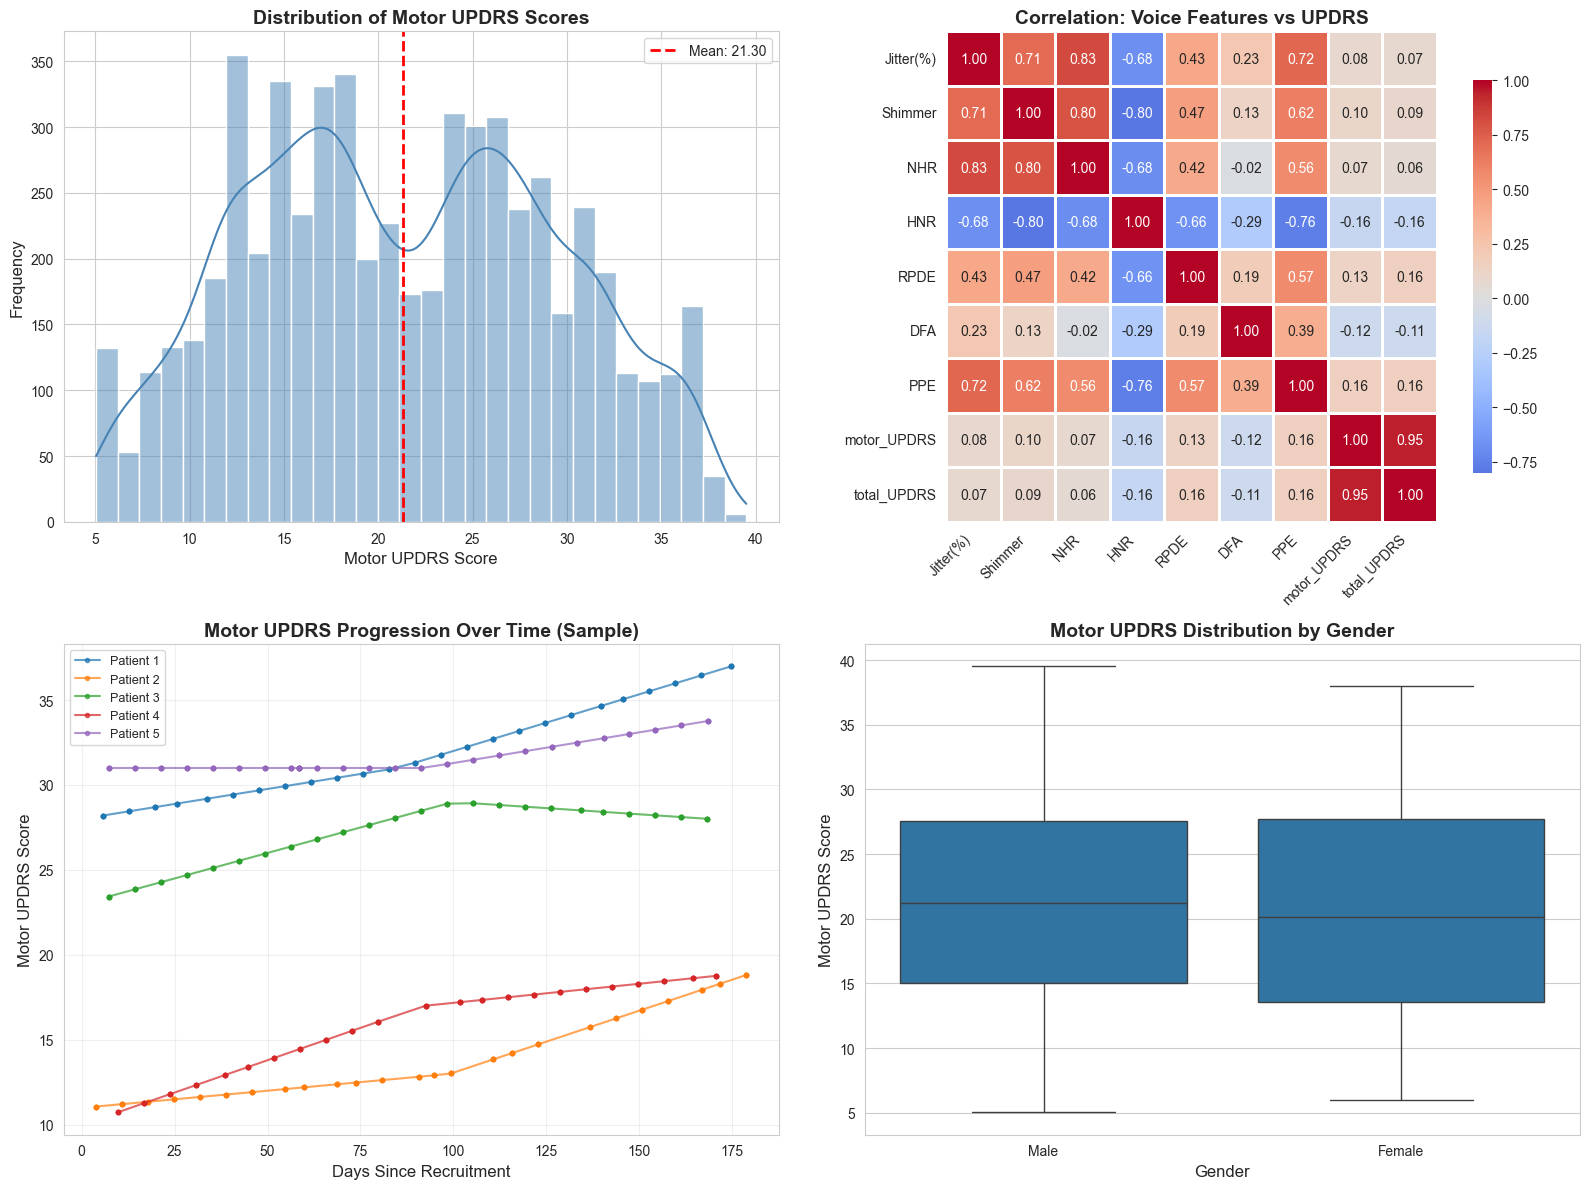

In [7]:
#GENERATING VISUALIZATIONS

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create figure with 4 subplots
fig = plt.figure(figsize=(16, 12))

# Visualization 1: Distribution of Motor UPDRS Scores

ax1 = plt.subplot(2, 2, 1)
sns.histplot(df['motor_UPDRS'], bins=30, kde=True, color='steelblue', ax=ax1)
ax1.set_title('Distribution of Motor UPDRS Scores', fontsize=14, fontweight='bold')
ax1.set_xlabel('Motor UPDRS Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.axvline(df['motor_UPDRS'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {df["motor_UPDRS"].mean():.2f}')
ax1.legend()

# Visualization 2: Correlation Heatmap

ax2 = plt.subplot(2, 2, 2)
voice_features = ['Jitter(%)', 'Shimmer', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 
                  'motor_UPDRS', 'total_UPDRS']
correlation_matrix = df[voice_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax2)
ax2.set_title('Correlation: Voice Features vs UPDRS', fontsize=14, fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Visualization 3: Disease Progression Over Time

ax3 = plt.subplot(2, 2, 3)
sample_patients = df['subject#'].unique()[:5]
for patient in sample_patients:
    patient_data = df[df['subject#'] == patient].sort_values('test_time')
    ax3.plot(patient_data['test_time'], patient_data['motor_UPDRS'], 
             marker='o', markersize=3, alpha=0.7, label=f'Patient {patient}')
ax3.set_title('Motor UPDRS Progression Over Time (Sample)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Days Since Recruitment', fontsize=12)
ax3.set_ylabel('Motor UPDRS Score', fontsize=12)
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# Visualization 4: Gender Comparison

ax4 = plt.subplot(2, 2, 4)
df['Gender'] = df['sex'].map({0: 'Male', 1: 'Female'})
sns.boxplot(x='Gender', y='motor_UPDRS', data=df, ax=ax4)
ax4.set_title('Motor UPDRS Distribution by Gender', fontsize=14, fontweight='bold')
ax4.set_ylabel('Motor UPDRS Score', fontsize=12)
ax4.set_xlabel('Gender', fontsize=12)

plt.tight_layout()
plt.savefig('parkinsons_eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()